# Fit nonlinear function to network performance

This script takes in the results from data-overview.ipynb, and performs a regression to extract the impact of different regulatory parameters on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle
import time

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import savgol_filter

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-1-'
comment = "acute_all-sparse-reg"
d = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/processed_full_data'+runs+'runs'+'-'+comment+'.pkl'
# d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
clustered_mean_df = pd.read_pickle(d_mean)
# '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl'
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/list_processed_full_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,b_I,d_I,K_I,I_0,S_0,N_0,d_S,K_H,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,harm_pI,harm_pS,max_eM_fold,frac_cM,log_T_pEcyteM,T_min_pI,T_max_pI,T_pE_start,T_pE_clear,stim_pI,stim_pHI,stim_pHE,scaled_min_pS,antigenicity_over_harm,harm_pI_noprotection,peff_clearance,peff_toxicity,peff_protection
0,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,0.666667,1.333333,-0.666667,0.0,0.666667,1.333333,-0.666667,-1.0,0.0,0.0,-0.0,-27.0,-0.666667,-1.333333,0.666667,-3.0,2.890815e+04,1.233530e+07,0.0,0.517341,0.0,3.108,2.292,0.264,59.736,0.801641,0.007736,1.324599,0.030237,3.349148,1.386375,1.383485,1.233530,0.149955
1,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,0.666667,1.333333,-0.666667,0.0,0.666667,1.333333,-0.666667,-1.0,0.0,0.0,-0.0,-27.0,-0.666667,-1.333333,0.666667,-2.0,3.672570e+04,8.672641e+06,0.0,0.532738,0.0,3.336,2.472,0.204,41.808,0.931403,0.009712,1.130613,0.255935,3.349148,1.386375,1.382703,0.867264,0.515439
2,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,0.666667,1.333333,-0.666667,0.0,0.666667,1.333333,-0.666667,-1.0,0.0,0.0,-0.0,-27.0,-0.666667,-1.333333,0.666667,-1.0,6.622953e+04,5.334954e+06,0.0,0.555556,0.0,3.948,2.988,0.204,26.064,1.285198,0.016696,1.051316,0.515351,3.349148,1.386375,1.379752,0.533495,0.846257
3,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,0.666667,1.333333,-0.666667,0.0,0.666667,1.333333,-0.666667,-1.0,0.0,0.0,-0.0,-27.0,-0.666667,-1.333333,0.666667,0.0,2.067322e+05,4.089908e+06,0.0,0.449735,0.0,5.088,3.984,0.408,27.180,2.166443,0.049248,0.969333,0.625193,3.349148,1.386375,1.365702,0.408991,0.956711
4,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,0.666667,1.333333,-0.666667,0.0,0.666667,1.333333,-0.666667,-1.0,0.0,0.0,-0.0,-27.0,-0.666667,-1.333333,0.666667,1.0,2.217683e+06,1.858623e+06,0.0,0.359897,0.0,7.164,5.892,0.408,59.592,4.582274,0.488349,2.622388,0.616087,3.349148,1.386375,1.164607,0.185862,0.978745
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27529861,1.000000e-01,0.01,100000000.0,500000.0,10000000.0,1000.0,0.01,100000.0,2.000000,0.666667,0.000000,-3.0,2.000000,0.666667,0.000000,-1.0,0.0,0.0,0.0,-27.0,-2.000000,-0.666667,-0.000000,-1.0,2.407050e+07,0.000000e+00,0.0,0.000000,0.0,0.000,60.000,60.000,-60.000,0.115872,0.923593,0.000000,0.101182,3.172940,2.407050,0.000000,0.000000,0.000000
27529862,1.000000e-01,0.01,100000000.0,500000.0,10000000.0,1000.0,0.01,100000.0,2.000000,0.666667,0.000000,-3.0,2.000000,0.666667,0.000000,-1.0,0.0,0.0,0.0,-27.0,-2.000000,-0.666667,-0.000000,0.0,2.407050e+07,0.000000e+00,0.0,0.000000,0.0,0.000,60.000,60.000,-60.000,0.115872,0.923593,0.000000,0.101182,3.172940,2.407050,0.000000,0.000000,0.000000
27529863,1.000000e-01,0.01,100000000.0,500000.0,10000000.0,1000.0,0.01,100000.0,2.000000,0.666667,0.000000,-3.0,2.000000,0.666667,0.000000,-1.0,0.0,0.0,0.0,-27.0,-2.000000,-0.666667,-0.000000,1.0,2.407050e+07,0.000000e+00,0.0,0.000000,0.0,0.000,60.000,60.000,-60.000,0.115872,0.923593,0.000000,0.101182,3.172940,2.407050,0.000000,0.000000,0.000000
27529864,1.000000e-01,0.01,100000000.0,500000.0,10000000.0,1000.0,0.01,100000.0,2.000000,0.666667,0.000000,-3.0,2.000000,0.666667,0.000000,-1.0,0.0,0.0,0.0,-27.0,-2.000000,-0.666667,-0.000000,2.0,2.407050e+07,0.000000e+00,0.0,0.000000,0.0,0.000,60.000,60.000,-60.000,0.115872,0.923593,0.000000,0.101182,3.172940,2.407050,0.000000,0.000000,0.000000


In [3]:
# Define parameters
num_categories = len(perf_vars)
num_modules = len(modules)
num_psis = len(Na_reg)

module_reg = {'Na': [r for r in Na_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'NE': [r for r in NE_reg if np.std(infection_scenarios[10][r].values) > 0],  
              'EE': [r for r in EE_reg if np.std(infection_scenarios[10][r].values) > 0]}

module_reg_labels = {'Na': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['Na']], 
                     'NE': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['NE']],
                     'EE': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['EE']]}
reg_label = param_names[-16:-12] + param_names[-12:-8] + param_names[-4:]
signal_classes = [r for i, r in enumerate(["Ag.", "Inf. harm", "Resp. harm", "Baselines"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]

reg = [r for r in Na_reg + NE_reg + EE_reg if np.std(infection_scenarios[10][r].values) > 0]
key_var = 'antigenicity_over_harm'
n_virs = len(infection_scenarios)
cmap_colors = sns.color_palette('tab20c', 20)
tol = 1e-2

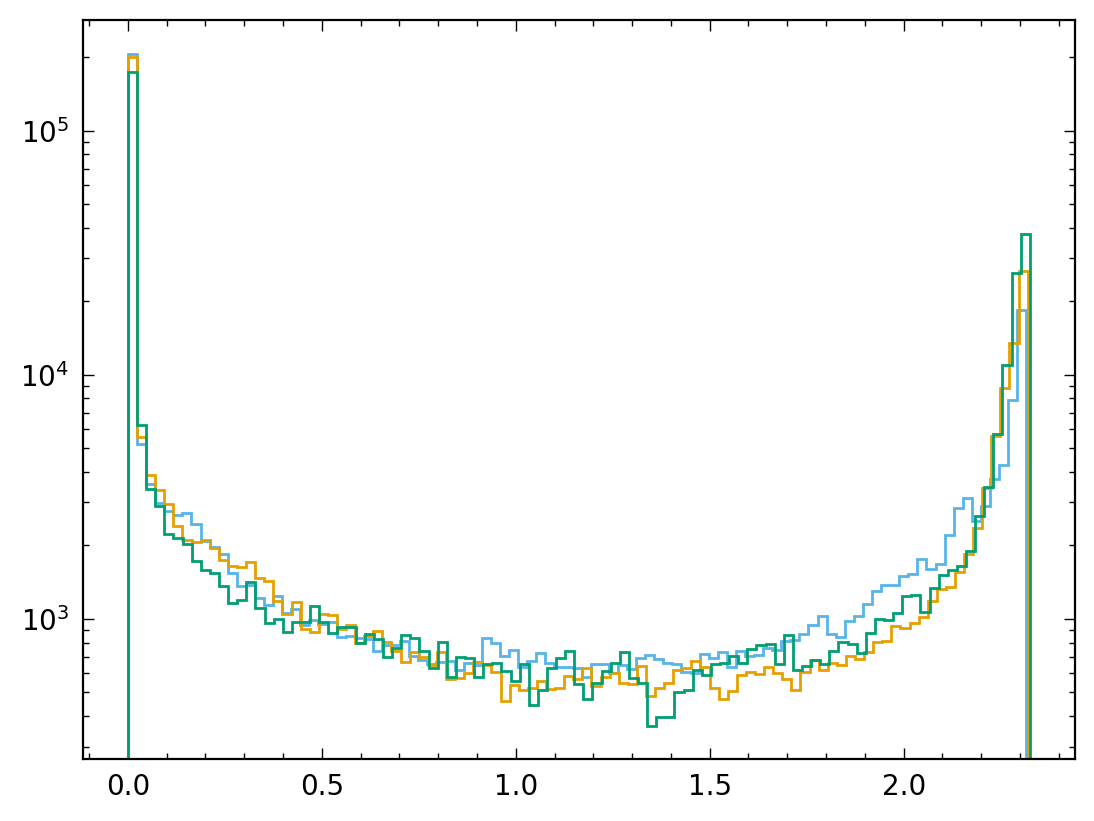

In [4]:
# Inspect distribution of observables
sel = 'peff_clearance'
for a in np.unique(clustered_mean_df.loc[(clustered_mean_df.b_I == b_C)][key_var].values):
    data = clustered_mean_df.loc[clustered_mean_df[key_var] == a]
    plt.hist(data[sel], bins = np.linspace(np.amin(data[sel]), np.amax(data[sel]), 100), histtype = 'step', log = True);

,antigenicity_over_harm,stim_pI,stim_pHI,stim_pHE
0,0.532046,0.000100,0.003307,3.309334
1,0.544286,0.002457,0.159179,3.313155
2,0.556817,0.009260,0.474249,3.327553
3,0.562162,0.000164,0.003307,3.312044
4,0.569737,0.020708,0.815945,3.309368
...,...,...,...,...
223,3.120998,6.309190,2.026831,3.389074
224,3.172940,0.115872,0.923593,3.681662
225,3.349148,6.526541,1.793700,3.528564
226,5.611731,0.801340,0.923593,3.934052


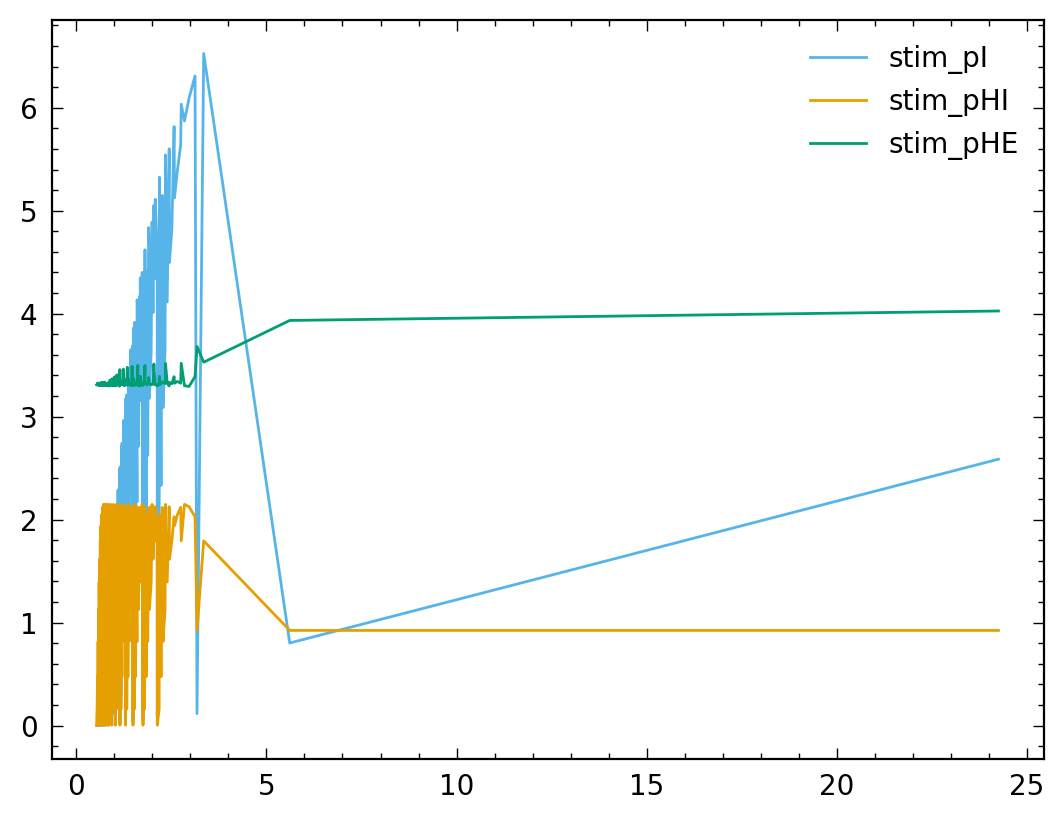

In [5]:
#norm_stim = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[reg_stim]), axis = 1) == 0)].groupby(key_var, as_index = False).mean()[[key_var, 'stim_pI', 'stim_pHI', 'stim_pHE']]
norm_stim = clustered_mean_df.groupby(key_var, as_index = False).max()[[key_var, 'stim_pI', 'stim_pHI', 'stim_pHE']]
with pd.option_context('display.max_columns', None):
    display(norm_stim)
    
plt.plot(norm_stim[key_var], norm_stim[['stim_pI', 'stim_pHI', 'stim_pHE']], label = ['stim_pI', 'stim_pHI', 'stim_pHE'])
plt.legend()

In [6]:
# # Explore noise in the data
# fig, axs = plt.subplots(1, len(perf_vars), 
#                               figsize=(len(perf_vars)**2 - len(perf_vars), 4), sharex=True, sharey=False)


# data_mean = clustered_mean_df.groupby(reg + vir_vars, as_index = False).std()
        
# for i, var in enumerate(perf_vars):
#     im = axs[i].scatter(data_mean[reg_choice[j]]/np.amax(data_mean[reg_choice[j]]), 
#                         (10**data_mean[var] - 1) if i == 4 or i == 5 else data_mean[var], 
#                       marker = 's', s = 50, color = cmap_colors[module_index*len(reg_choice) + j], 
#                         edgecolors = 'None',label = reg_label[module_index*len(reg_choice) + j ])

#     if module_index + j == 0: 
#         axs[i].minorticks_off()
#         axs[i].yaxis.set_tick_params(labelbottom=True)
#         axs[i].xaxis.set_tick_params(labelbottom=True)
#         axs[i].tick_params(axis='both', which='major', labelsize=8)
#         axs[i].set_box_aspect(1)
#         axs[i].locator_params(axis='y', nbins=4)
#         axs[i].locator_params(axis='x', nbins=4)
#         axs[i].set_ylabel("St. dev.\n"+perf_labels[i], fontsize = 12)
#         axs[i].set_xlabel(r'Design variables,$\{\vec\psi, \vec L_0 \}$', fontsize = 12)

# axs[-1].legend(bbox_to_anchor=(1.1, 1), fontsize=10, framealpha=0, ncol = 2)
# fig.subplots_adjust(wspace=.4, hspace=.35)
# #plt.savefig('_figs/'+comment+'-'+'mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")

### Fit model to average data
The nonlinear sigmoid model does a good job on the data averaged over infections and marginalized over modules. This is the minimum we require.

fevals: 8
fevals: 33
fevals: 8
fevals: 27
fevals: 8
fevals: 33
fevals: 8
fevals: 13
fevals: 8
fevals: 33
fevals: 8
fevals: 10


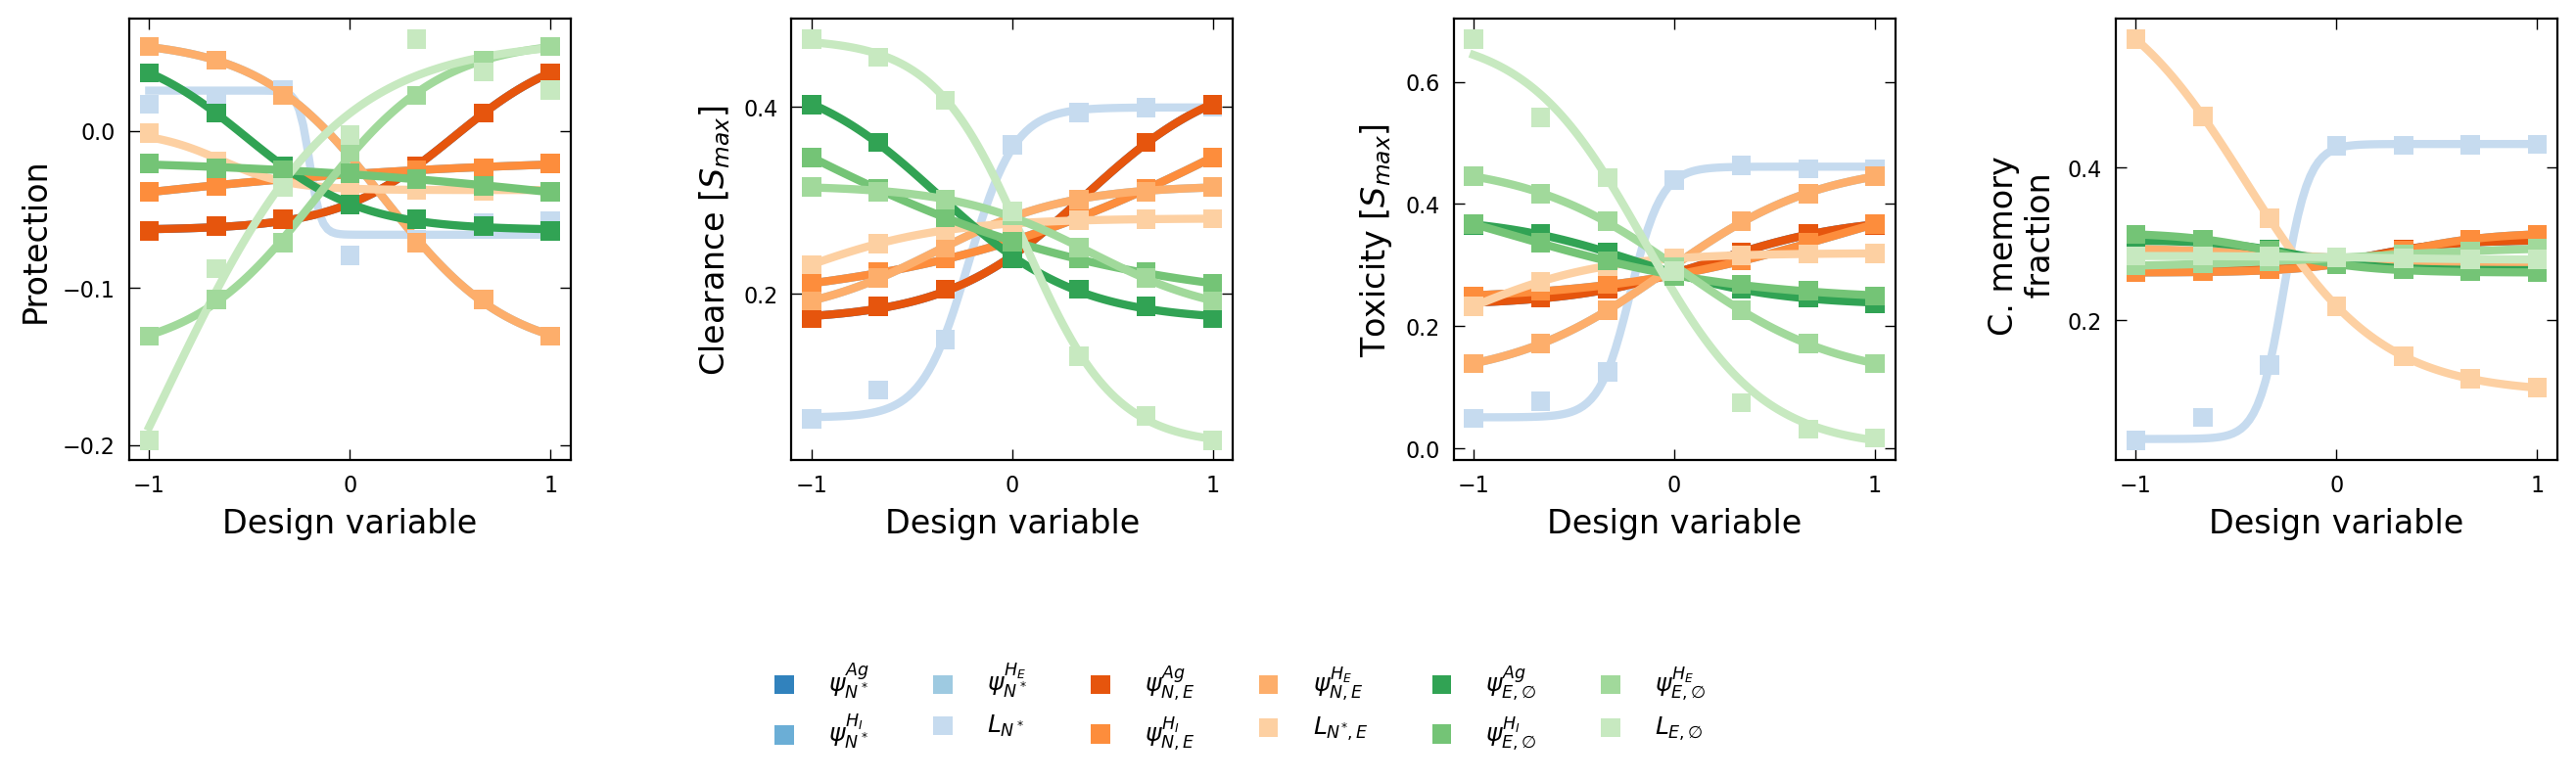

In [7]:
# Fit impact of regulatory parameters on performace: marginalizing over modules
fig, axs = plt.subplots(1, len(perf_vars), 
                              figsize=(len(perf_vars)**2, len(perf_vars)), sharex=True, sharey=False)

for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    zero_regs = np.concatenate([(module_reg[modules[u]] if u != module_index else []) for u in np.arange(0, len(modules))]).tolist()
    
    x_varname= key_var

    for j, p in enumerate(signal_classes):
        data_mean = clustered_mean_df.groupby(reg_choice[j], as_index = False).mean()
        
        for i, (var, ax) in enumerate(zip(perf_vars, axs.flat)):
            im = ax.scatter(data_mean[reg_choice[j]]/np.amax(data_mean[reg_choice[j]]), 
                                (10**data_mean[var] - 1) if i == 4 or i == 5 else data_mean[var], 
                              marker = 's', s = 50, color = cmap_colors[module_index*len(reg_choice) + j], 
                                edgecolors = 'None',label = reg_label[module_index*len(reg_choice) + j ])

            y_max = np.max(data_mean[var].values)
            y_min = np.min(data_mean[var].values)
            y_std = np.std(data_mean[var].values)

            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - tol*y_std, np.minimum(2*y_min, 0), -4*L0_max, -4*L0_max], 
                                             [2*y_max if y_max > 0 else y_std*tol, np.maximum(y_min, 0) + y_std*tol, 4*L0_max, 4*L0_max]),
                                   maxfev=10000,
                                   full_output = True)

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            ax.plot(x/np.amax(x), (10**sigmoid_1d(x, *popt) - 1) if i == 4 or i == 5 else sigmoid_1d(x, *popt), 
                        linestyle='-',
                        linewidth = 3.0,
                        color = cmap_colors[module_index*len(reg_choice) + j],
                        #label = reg_label[module_index*len(reg_choice) + j ],
                        zorder = 0)

            if i == 0:
                print("fevals:", infodict['nfev'])

            if module_index + j == 0: 
                ax.minorticks_off()
                ax.yaxis.set_tick_params(labelbottom=True)
                ax.xaxis.set_tick_params(labelbottom=True)
                ax.tick_params(axis='both', which='major', labelsize=8)
                ax.set_box_aspect(1)
                ax.locator_params(axis='y', nbins=4)
                ax.locator_params(axis='x', nbins=4)
                ax.set_ylabel(perf_labels[i], fontsize = 12)
                ax.set_xlabel(r'Design variable', fontsize = 12)

axs[1].legend(loc='lower center', bbox_to_anchor=(1.0, -0.71), fontsize=9, framealpha=0, ncol=len(reg_label) // 2)

#legend(bbox_to_anchor=(1.1, 1), fontsize=12, framealpha=0, ncol = 2)
fig.subplots_adjust(wspace=.5, hspace=.35)
plt.savefig('_figs/'+comment+'-'+'mean_regulation_trends_by_performance'+'.png', dpi=300, bbox_inches="tight")

In [8]:
del clustered_mean_df

### Fit model to individual infection scenarios and with all regulatory modules as variables

In [11]:
# Regress Performance measures on regulation parameters
num_cpu = 145
variables = reg
tol = 1e-2
fit = "sigmoid_nonlinear"

def model(input, fit = fit):

    out = []
    infection = input[vir_vars].values[0]
    runtimes = str(np.round(infection, 3))+': '
    
    for i, perf in enumerate(perf_vars):
        # run regression
        start = time.time() # timestamp start
        
        if fit == "linear":
            input.loc[:,'dep_var'] = np.log(1 + input[perf].values) if 'Memory' in perf_labels[perf_vars.index(perf)] or 'magnitude' in perf_labels[perf_vars.index(perf)] else input[perf].values
            lr = smf.ols('dep_var ~ ' + ' + '.join(variables), data=input).fit()
    
            # save values
            out.append( (lr.params.values[0: 1 + len(variables)]).tolist() + np.sqrt(np.diag(lr.cov_params())).tolist() + infection.tolist() + [np.mean(input[perf].values), i] )
        
        elif fit == "sigmoid_linear":
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(sigmoid, input[variables].values, input[perf].values, 
                           p0 =[y_max, y_min] + len(variables)*[0.0] + num_modules*[0.0],
                           method = 'trf', 
                           bounds = ([y_max - y_std*tol, np.minimum(0.0, y_min)] + len(variables)*[-15*L0_max] + num_modules*[-15*L0_max], 
                                     [1.0 if perf == "frac_cM" else (y_max + y_std*tol), y_min + y_std*tol] + len(variables)*[15*L0_max] + num_modules*[15*L0_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), 
                                                                                               np.max(input[perf].values), 
                                                                                               np.min(input[perf].values), 
                                                                                               np.median(input[perf].values), 
                                                                                               i, rmse, y_std, 
                                                                                               np.amax(input['scaled_min_pS'].values),
                                                                                               input['harm_pI_noprotection'].values[0],
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pI'].values), 
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHI'].values),
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHE'].values),
                                                                                               ])
            
        elif fit == "sigmoid_nonlinear":
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(modified_sigmoid, input[variables].values, input[perf].values, 
                           p0 = [y_max, y_min] + len(variables)*[0.0] + num_modules*[0.0] + (3*num_modules)*[0.0],
                           method = 'trf', 
                           bounds = ([y_max - y_std*tol, np.minimum(0.0, y_min)] + len(variables)*[-15*L0_max] + num_modules*[-15*L0_max] + (3*num_modules)*[-15*L0_max], 
                                     [1.0 if perf == "frac_cM" else (y_max + y_std*tol), y_min + y_std*tol] + len(variables)*[15*L0_max] + num_modules*[15*L0_max] + (3*num_modules)*[15*L0_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - modified_sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), 
                                                                                               np.max(input[perf].values), 
                                                                                               np.min(input[perf].values), 
                                                                                               np.median(input[perf].values), 
                                                                                               i, rmse, y_std, 
                                                                                               np.amax(input['scaled_min_pS'].values),
                                                                                               input['harm_pI_noprotection'].values[0],
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pI'].values), 
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHI'].values),
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHE'].values),
                                                                                               ])

            # if i == 0:
            #     print("fevals:", infodict['nfev'])
        end = time.time() # timestamp start
        runtimes += (perf+ ' = ' + str((end - start)/3600)+' hrs, ')
        
    #print(runtimes)
    out_data = pd.DataFrame(np.vstack(out), 
                            columns = ['y_max', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ([('interact_' + str(j)) for j in np.arange(0, 9)] if fit == "sigmoid_nonlinear" else []) \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + ([('sigma_interact_' + str(j)) for j in np.arange(0, 9)] if fit == "sigmoid_nonlinear" else []) \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'max_scaled_min_pS', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
    out_data['antigenicity_over_harm'] = antigenicity_over_harm(out_data)
    out_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'+comment+runs+'fit_'+str(np.round(infection, 3))+'.pkl')
    
    return np.vstack(out)

# Compile datasets
impact_data = pd.DataFrame(np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(model)(input = data.groupby(vir_vars + variables, as_index=False).mean(), fit = "sigmoid_nonlinear") 
                                                                                                            for data in infection_scenarios)), 
                            columns = ['y_max', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ([('interact_' + str(j)) for j in np.arange(0, 9)] if fit == "sigmoid_nonlinear" else []) \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + ([('sigma_interact_' + str(j)) for j in np.arange(0, 9)] if fit == "sigmoid_nonlinear" else []) \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'max_scaled_min_pS', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [12]:
# # IF the above fails: Compile datasets
# num_cpu = 150
# file_list = [f for f in os.listdir(d) if comment in f]
# num_files = len(file_list)

# def import_fits(f,d):
    
#     file_path = os.path.join(d, f)
#     with open(file_path, 'rb') as filename:  
#         out = pickle.load(filename)

#     return out

# impact_data = pd.concat(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(import_fits)(f = file_name, d = d) 
#                                                                                                             for file_name in file_list))
# impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

# impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [13]:
# View result
perf_choice = 1 # chose observable
impact_data = pd.read_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')
with pd.option_context('display.max_columns', None,'display.max_rows', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EE,interact_0,interact_1,interact_2,interact_3,interact_4,interact_5,interact_6,interact_7,interact_8,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EE,sigma_interact_0,sigma_interact_1,sigma_interact_2,sigma_interact_3,sigma_interact_4,sigma_interact_5,sigma_interact_6,sigma_interact_7,sigma_interact_8,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,max_scaled_min_pS,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
1,1.391223e+00,7.090256e-14,2.857176,0.183000,0.225022,1.898763,1.800411,0.040926,0.202981,1.819374,-3.585034,-0.269347,-0.374751,-1.844095,2.035680,6.450472,0.787573,-14.005511,0.016220,-0.014716,-0.024770,0.096575,0.038049,0.046568,0.032531,0.052074,1.308648e-03,9.537286e-04,1.935166e-02,6.471603e-03,6.535592e-03,1.346757e-02,3.041297e-02,1.373405e-02,1.407500e-02,4.347875e-02,2.174838e-02,5.373967e-03,5.596675e-03,1.172549e-02,1.769731e-02,1.283100e-01,9.565708e-03,8.709631e-17,6.279424e-03,6.285216e-03,3.800086e-03,1.967601e-02,1.941868e-02,9.724376e-03,5.121946e-03,5.132265e-03,0.150000,1.000000e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,5.871113e-01,1.384963e+00,0.000000e+00,0.216619,1.0,1.983309e-01,6.259814e-01,0.983330,1.386375,6.526541,1.793700,3.127044,3.349148
5,1.390859e+00,1.566809e-14,2.268633,0.169777,0.213112,1.832293,1.301612,0.035927,0.190673,1.760632,-3.166078,-0.256517,-0.388047,-1.940841,1.949192,6.264794,0.833301,-15.050724,0.011726,-0.020643,-0.024955,0.040370,-0.037576,0.037792,0.054120,0.112430,1.506118e-03,1.034304e-03,1.522432e-02,6.140774e-03,6.205686e-03,1.255869e-02,2.194744e-02,1.251209e-02,1.271817e-02,4.293985e-02,1.985009e-02,5.344382e-03,5.644375e-03,1.248387e-02,1.656476e-02,1.261603e-01,9.682381e-03,5.763968e-17,5.085828e-03,5.095773e-03,3.603919e-03,1.465727e-02,1.469208e-02,9.051548e-03,4.405336e-03,4.463143e-03,0.150000,1.637894e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,5.663972e-01,1.384746e+00,0.000000e+00,0.186586,1.0,2.094647e-01,6.113663e-01,0.973394,1.386375,6.034064,1.793700,3.131562,2.758122
9,1.390212e+00,1.810007e-04,1.827662,0.161923,0.231549,1.772070,0.976243,0.023789,0.198711,1.866414,-2.762684,-0.262019,-0.423245,-1.971688,1.829375,6.659394,0.701563,-19.803157,0.020116,-0.035647,-0.015645,0.002441,-0.128324,-0.003585,0.075469,0.177520,1.654686e-03,1.067362e-03,1.259805e-02,5.791944e-03,5.898242e-03,1.173890e-02,1.794360e-02,1.215013e-02,1.234436e-02,5.047486e-02,1.732044e-02,5.238511e-03,5.619260e-03,1.238540e-02,1.531787e-02,1.492047e-01,9.109080e-03,2.811746e-16,4.418822e-03,4.445875e-03,3.438582e-03,1.233540e-02,1.263060e-02,8.954661e-03,3.994333e-03,4.142283e-03,0.150000,2.682696e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,5.402505e-01,1.384249e+00,0.000000e+00,0.150915,1.0,2.129816e-01,5.963142e-01,0.944108,1.386375,5.542180,1.793700,3.122609,2.344404
13,1.389621e+00,5.825081e-03,1.486700,0.164378,0.272192,1.755672,0.622544,0.009357,0.212325,1.799892,-2.424165,-0.280269,-0.499216,-2.029215,1.693807,6.637884,0.491077,13.472061,0.034949,-0.044349,-0.013650,-0.035433,-0.163780,0.004267,0.087401,0.199677,1.813388e-03,1.070132e-03,1.069746e-02,5.580003e-03,5.758534e-03,1.125097e-02,1.534340e-02,1.229442e-02,1.266831e-02,5.848979e-02,1.561006e-02,5.204532e-03,5.804263e-03,1.281835e-02,1.421095e-02,1.741634e-01,8.478462e-03,2.248656e-16,4.129028e-03,4.165466e-03,3.430997e-03,1.096308e-02,1.123449e-02,9.262727e-03,3.806714e-03,3.987801e-03,0.150000,4.393971e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,5.111946e-01,1.383796e+00,0.000000e+00,0.098610,1.0,2.142435e-01,5.825081e-01,0.889531,1.386375,5.05

#### Check the model goodness of the fit
The model does a pretty good job as the $R^2$ values for clearance, toxicity and memory are above 0.80.

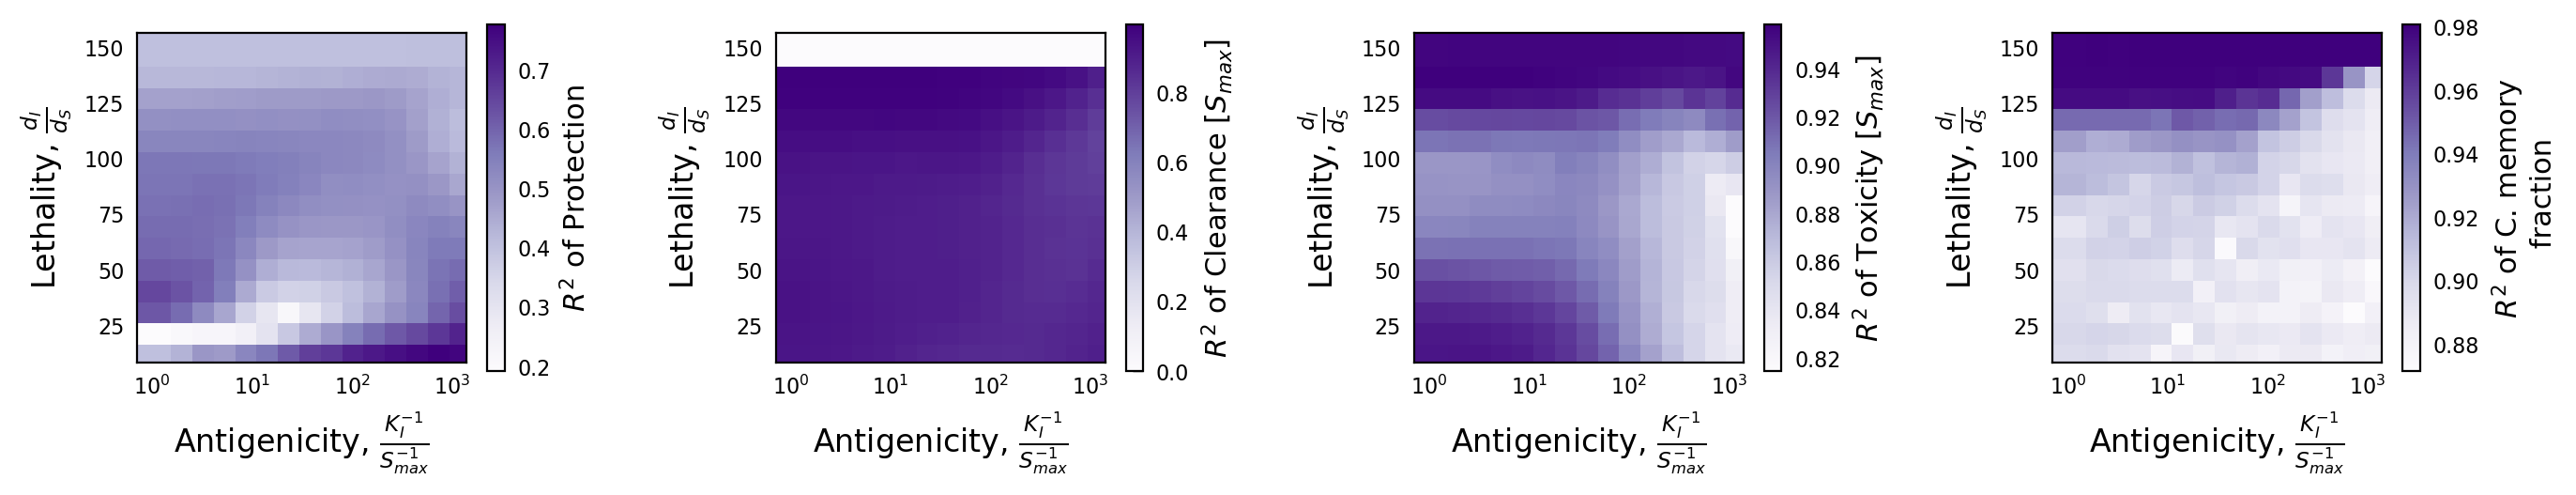

In [14]:
# Examine goodness of fit through R-squared
plots = [vir_vars[1], vir_vars[0]]
plot_labels = ["Antigenicity, "+r"$\frac{K_{I}^{-1}}{S_{max}^{-1}}$", "Lethality, "+r"$\frac{d_{I}}{d_{S}}$"]
size = 3200/np.sqrt(len(infection_scenarios))

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    model_r_sq = (1 - data.rmse**2/data.y_std**2)*(data.y_std > tol)
    z_label = r"$R^2$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = model_r_sq, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.55, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-r-squared'+'.png', dpi=150, bbox_inches="tight")

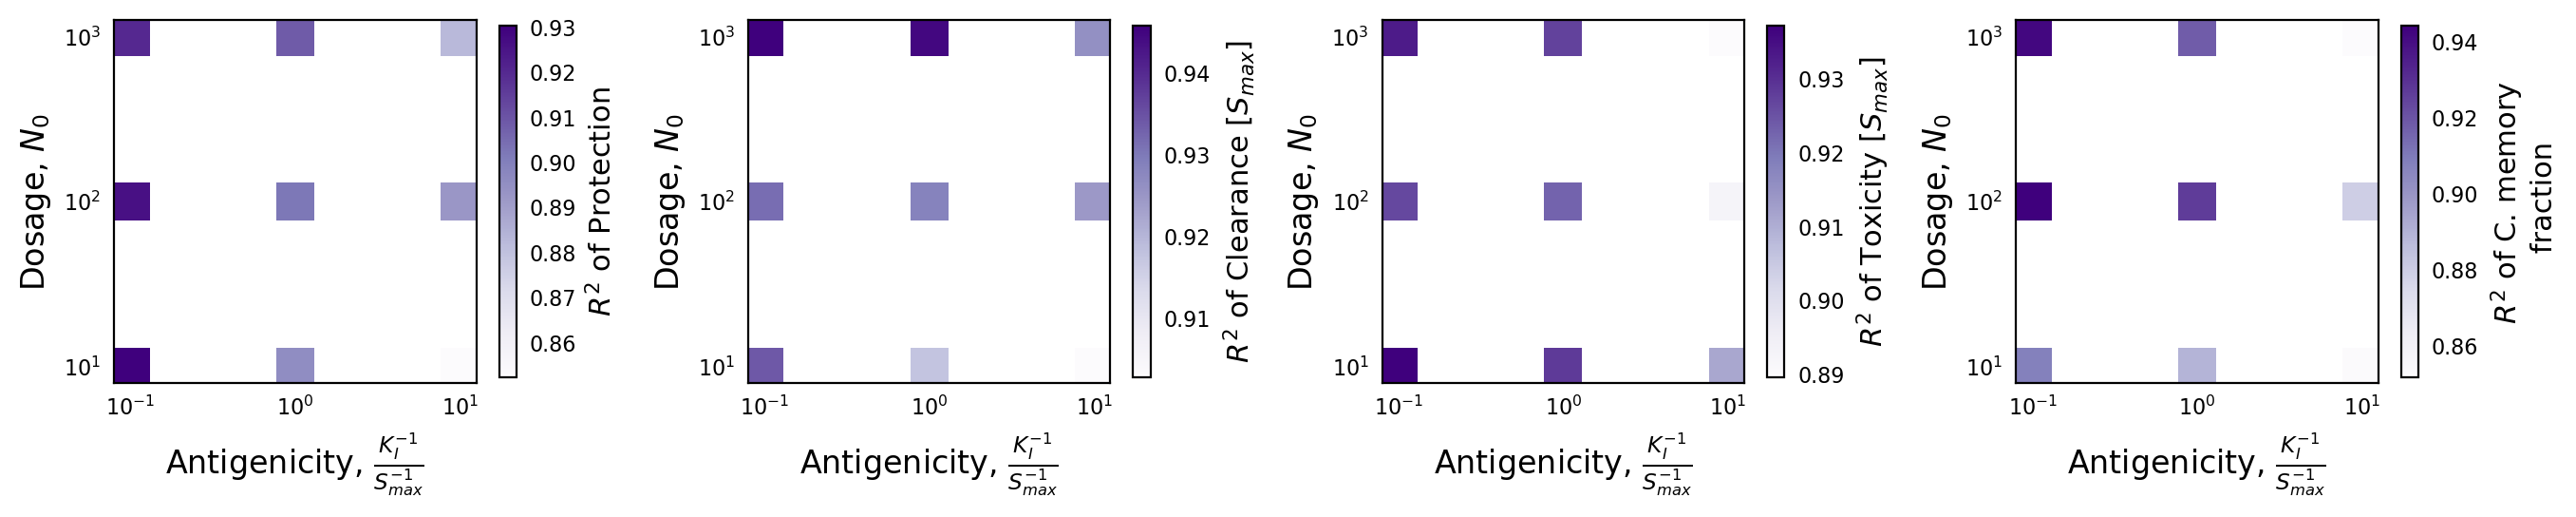

In [15]:
# Examine goodness of fit through R-squared
size = 3200/np.sqrt(len(infection_scenarios))

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = vir_vars[1], vir_vars[4]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 > I_min)]
    model_r_sq = (1 - data.rmse**2/data.y_std**2) #*(data.y_std > tol)
    z_label = r"$R^2$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname], data[y_varname],
                      marker ='s', s = size, c = model_r_sq, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    axs[i].semilogx()
    axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel("Antigenicity, "+r"$\frac{K_{I}^{-1}}{S_{max}^{-1}}$", fontsize = 12)
    ax.set_ylabel("Dosage, "+r"$N_0$", fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-r-squared-cancers'+'.png', dpi=150, bbox_inches="tight")

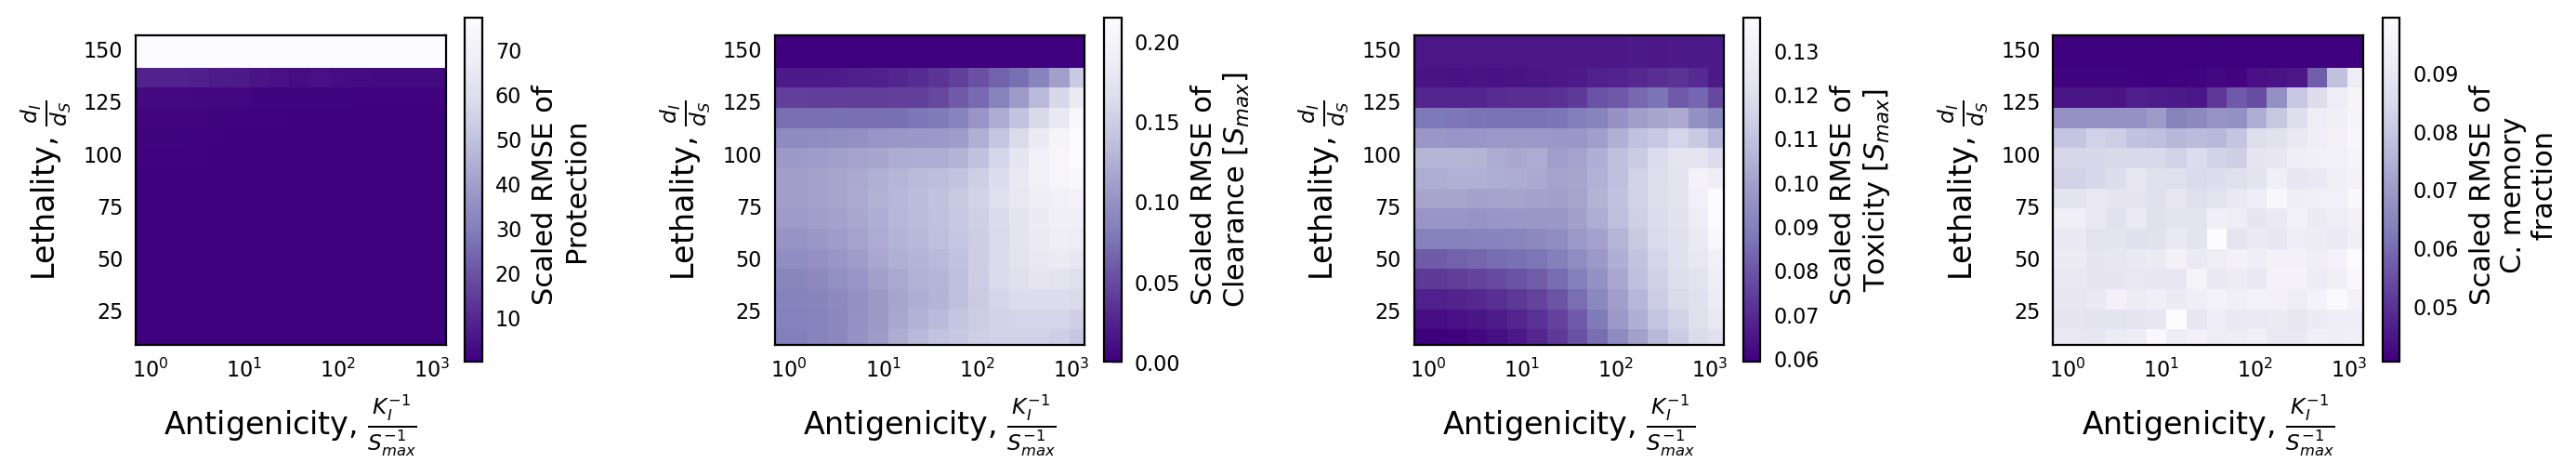

In [16]:
# Examine goodness of fit through scaled-RMSE
fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    model_rmse_over_max = (data.rmse/data.y_max)*(data.y_std > tol)
    z_label = "Scaled RMSE of \n"+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, 
                        c = model_rmse_over_max, cmap='Purples_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.65, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-scaled-rmse'+'.png', dpi=150, bbox_inches="tight")

Effector memory expansion appears challenging to fit based on the $R^2$ values. Looks much better when we look at scaled RMSE. Rationalize by observing tha effector memory expansion has non-monotonic dependence on some variables which can lead to a low variance estimate, and make the $R^2$ values look bad.

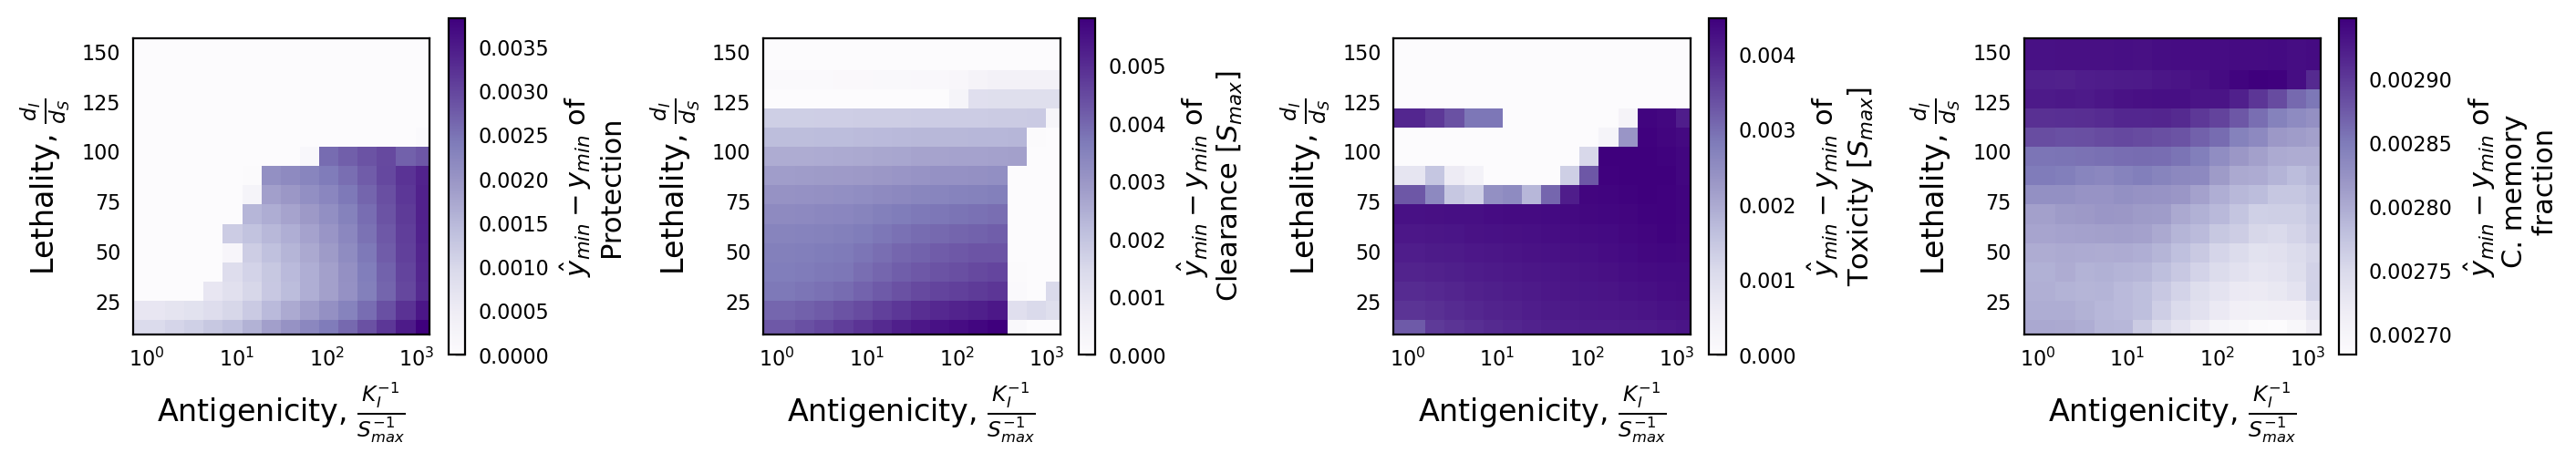

In [17]:
# Examine difference between observed and predicted minima
fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    z_label = r"$\hat{y}_{min} - y_{min}$"+ " of\n"+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = (data.y_min - data.min_perf)*(data.y_std > tol), cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.7, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_min'+'.png', dpi=150, bbox_inches="tight")

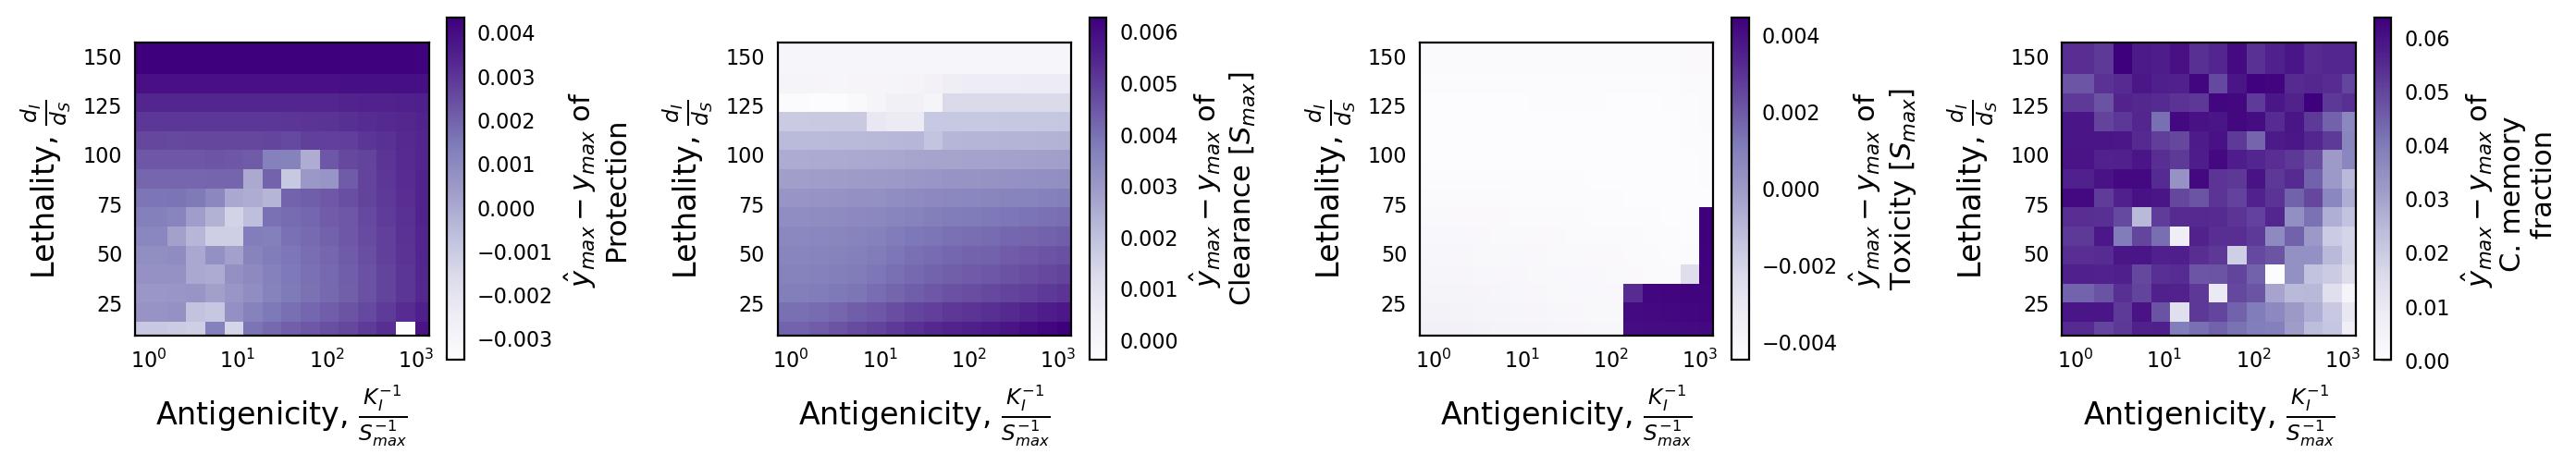

In [18]:
# Examine difference between observed and predicted maxima
plots = [vir_vars[1], vir_vars[0]]

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    z_label = r"$\hat{y}_{max} - y_{max}$ of"+"\n"+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = (data.y_max - data.max_perf)*(data.y_std > tol), cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.75, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_max'+'.png', dpi=150, bbox_inches="tight")

The distribution of the values of the bias parameters gives us a sense of how well our simulations can explain variation due to that module. In this case the Naive to Memory module has a computed bias for clearance/toxicity that is at the maximum allowable. However the value is less extreme for memory formation. This suggests a strong bias towards high clearance/toxicity in this module.

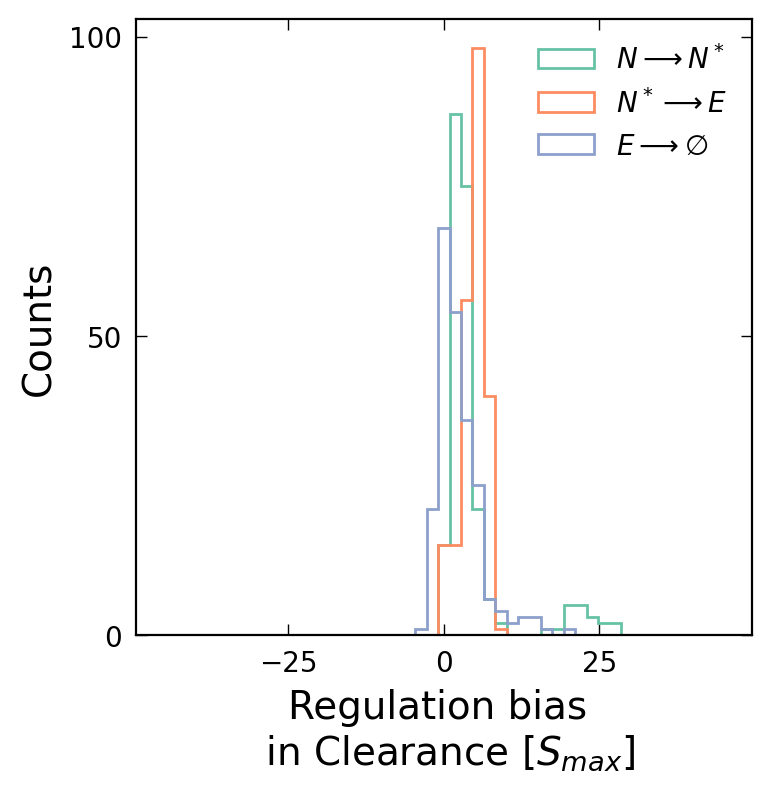

In [19]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data.I_0 <= I_min)]['intercept_'+r].values
    axs.hist(data, bins = np.linspace(-15*L0_max, 15*L0_max, 50), histtype = 'step', label = module_labels[i], color = cmap_colors[i], stacked = True);

axs.legend(fontsize = 10, ncol = 1)

axs.set_xlabel("Regulation bias \n in "+perf_labels[perf_choice], fontsize = 14)
axs.set_ylabel("Counts", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

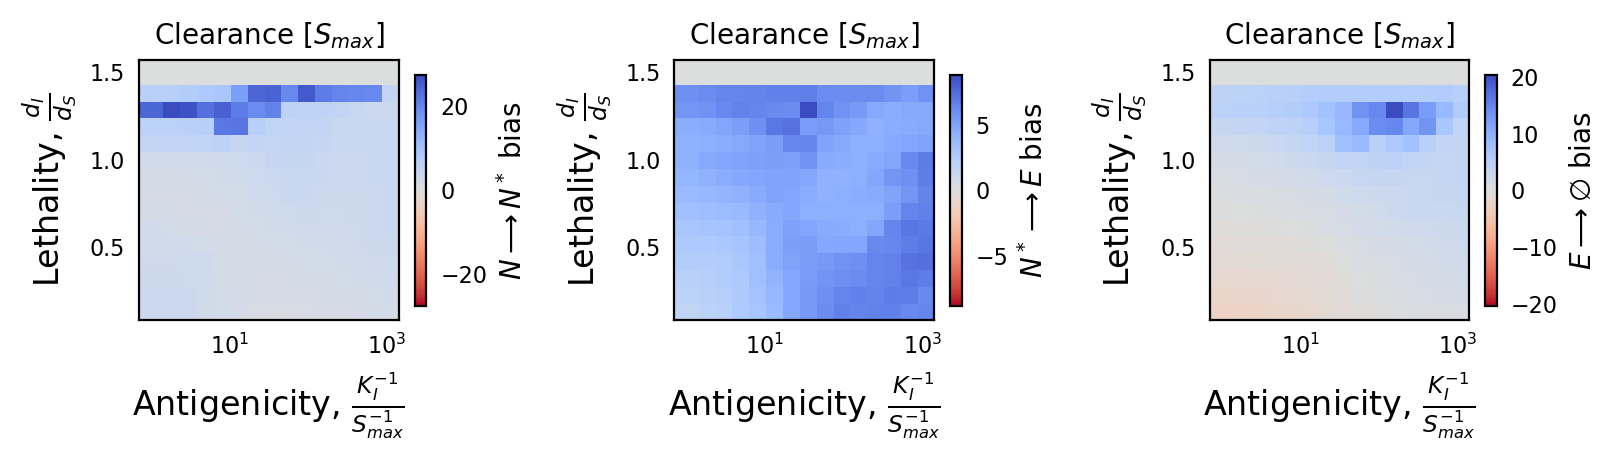

In [20]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
size = 1250/np.sqrt(len(infection_scenarios))

data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data.I_0 <= I_min)]

fig_c, axs = plt.subplots(1, len(modules), 
                          figsize=(len(modules)**2, 2*len(modules)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, r in enumerate(modules):
    z_varname = 'intercept_'+r
    z_label = module_labels[i]+" bias"
    z = data[z_varname]
    range = np.amax(np.abs(z))
    
    im = axs[i].scatter(S_0/data[x_varname] if x_varname == 'K_I' else data[x_varname],
                                 1/data[y_varname] if y_varname == 'K_I' else data[y_varname],
                      marker ='s', s = size, c = z, cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize(vmin = -range, vmax = range))

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)
    axs[i].set_title(perf_labels[perf_choice], fontsize = 10.0)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.25, pad = 0.05)
    cb.set_label(z_label, fontsize = 10)
    cb.ax.tick_params(labelsize=8)
    
fig_c.subplots_adjust(wspace=.65, hspace=0.5)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

# plt.savefig('_figs/'+comment+'-optimal-reg-average_prot_tox_hmap'+'.png', dpi=150, bbox_inches="tight")

These intercept values are important because they tell you what the value of the observable would be if we ran our processes, without regulation, at half their maximal characteristic rates. A positive value means that the half-max rate leads to above-median performance/cost. It would be useful to convert these to rates.

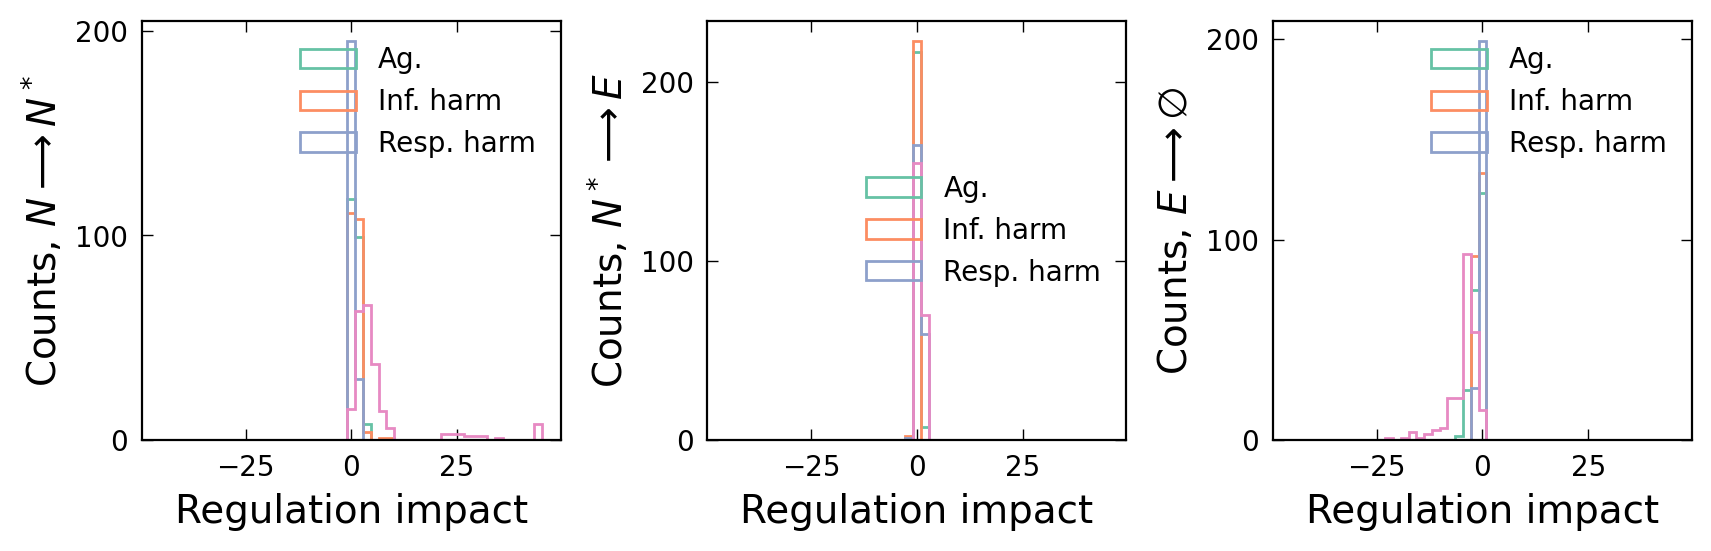

In [21]:
fig, axs = plt.subplots(1,3, figsize=(10,10), sharex=False, sharey=False)

for i, r in enumerate(reg):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data.I_0 <= I_min)][r].values
    module = i // num_psis
    cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    
    axs[module].hist(data, bins = np.linspace(-15*L0_max, 15*L0_max, 50), histtype = 'step', label = signal_classes[i % num_psis], color = cmap_colors[i % num_psis], stacked = True);

    if (i % num_psis) == num_modules -1:
        axs[module].legend(fontsize = 10, ncol = 1)
    
        axs[module].set_xlabel("Regulation impact", fontsize = 14)
        axs[module].set_ylabel("Counts, "+module_labels[i // num_psis], fontsize = 14)
        axs[module].set_box_aspect(1)
        axs[module].minorticks_off()
        axs[module].locator_params(axis='y', nbins=4)
        axs[module].locator_params(axis='x', nbins=4)

fig.subplots_adjust(wspace=.35, hspace=.25)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

In [22]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == 0.0)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EE,interact_0,interact_1,interact_2,interact_3,interact_4,interact_5,interact_6,interact_7,interact_8,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EE,sigma_interact_0,sigma_interact_1,sigma_interact_2,sigma_interact_3,sigma_interact_4,sigma_interact_5,sigma_interact_6,sigma_interact_7,sigma_interact_8,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,max_scaled_min_pS,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm


In [23]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == b_C)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EE,interact_0,interact_1,interact_2,interact_3,interact_4,interact_5,interact_6,interact_7,interact_8,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EE,sigma_interact_0,sigma_interact_1,sigma_interact_2,sigma_interact_3,sigma_interact_4,sigma_interact_5,sigma_interact_6,sigma_interact_7,sigma_interact_8,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,max_scaled_min_pS,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
901,2.314604,8.619628e-03,3.346886,1.503132,0.811246,3.416598,0.750081,0.352031,0.560908,1.391863,-1.006866,-0.595291,-1.338094,-2.097498,3.271168,4.424912,-1.984485,4.905063,0.213211,0.222363,0.152458,-0.069034,-0.042434,0.080050,0.010905,0.169162,0.002862,0.001081,0.027345,0.014033,0.010006,0.027273,0.010204,0.008483,0.009473,0.020422,0.006272,0.004887,0.007495,0.010223,0.028589,0.056332,0.010346,1.916523e-17,0.006035,0.006261,0.005755,0.007038,0.007277,0.006394,0.002967,0.003086,0.01,1000000.0,0.1,100000.0,10.0,10000000.0,500000.0,0.572614,2.305984,0.0,0.000363,1.0,0.268733,0.861963,0.761653,2.40705,2.586654,0.923593,2.108436,24.253500
905,2.309691,1.034584e-02,2.807422,1.319307,1.032664,3.107747,0.149767,0.141561,0.558829,1.249605,-3.516298,-1.848161,-1.077129,-4.879056,2.685483,5.907486,2.373342,-44.550000,0.171782,0.235444,0.117021,-0.108156,-0.137360,0.006345,0.018843,0.107327,0.002055,0.001219,0.016475,0.008757,0.007459,0.017757,0.017795,0.016949,0.016917,0.043406,0.023425,0.013209,0.008958,0.031569,0.016912,0.133089,0.017456,2.835341e-17,0.003877,0.003935,0.003629,0.009957,0.012318,0.011500,0.004232,0.004248,0.01,1000000.0,0.1,100000.0,100.0,10000000.0,500000.0,0.877220,2.316988,0.0,0.031957,1.0,0.283862,1.034584,0.749859,2.40705,2.586654,0.923593,3.175272,24.253500
909,2.335818,1.059415e-02,2.792888,1.321582,1.042305,3.180313,-0.813535,-0.518955,1.234018,0.045716,-4.284562,-2.216776,-1.350135,-5.570672,2.866551,5.253115,4.842260,11.281702,0.203694,0.221881,0.096119,-0.055295,-0.279977,-0.151440,0.185579,0.013558,0.002932,0.001284,0.015797,0.008434,0.007287,0.017512,0.076860,0.059107,0.090452,0.007865,0.030120,0.016345,0.011057,0.038495,0.017149,0.192852,0.034515,1.718631e-16,0.003746,0.003787,0.003534,0.020208,0.036987,0.025476,0.004688,0.004577,0.01,1000000.0,0.1,100000.0,1000.0,10000000.0,500000.0,0.973803,2.325224,0.0,0.172266,1.0,0.287752,1.059415,0.757848,2.40705,2.586654,0.923593,3.618618,24.253500
913,2.287669,6.596157e-03,1.325613,2.826015,0.670977,5.807091,0.130053,0.448132,0.357188,1.451273,-0.137897,-0.504969,-1.662068,-1.839710,5.247760,4.133311,-3.680480,-44.664754,0.504490,0.070184,0.096290,0.001054,-0.021859,0.021739,0.001669,0.013125,0.003295,0.000693,0.016772,0.028544,0.013023,0.053721,0.008379,0.009019,0.008834,0.015956,0.002986,0.003330,0.006742,0.007306,0.051844,0.044278,0.012890,1.657264e-16,0.007492,0.008089,0.008243,0.004690,0.006186,0.006129,0.002041,0.002184,0.01,10000000.0,0.1,100000.0,10.0,10000000.0,500000.0,0.340407,2.281073,0.0,0.000074,1.0,0.189263,0.659616,0.424602,2.40705,0.801340,0.923593,2.018706,5.611731
917,2.318114,1.660299e-04,0.943822,2.086792,1.274692,4.539088,-0.037089,0.015648,1.059762,0.383536,-0.360334,-1.275767,-1.050602,-3.283204,3.199512,2.849860,0.454661,44.696762,0.360833,0.065768,0.061087,-0.041283,-0.048467,-0.053120,-0.023041,0.021822,0.002888,0.001028,0.008477,0.014788,0.010166,0.029638,0.009542,0.009738,0.011503,0.004562,0.004983,0.007943,0.007244,0.017369,0.022715,0.024691,0.007088,3.675025e-17,0.004720,0.004481,0.004734,0.003678,0.006117,0.006263,0.003239,0.003455,0.01,10000000.0,0.1,100000.0,100.0,10000000.0,5